In [1]:
# --- PARAMETERS (Injected via Papermill) ---
HIDDEN_DIM = 128
NUM_LAYERS = 3
TRAIN_RATIO = 0.8       # 0.8 means we train on 80% of pairs, test on 20%
BATCH_SIZE = 1       # 1024
NUM_ITERATIONS = 100  # 50000
LEARNING_RATE = 0.0001
GRID_SIZE = 9
SEED = 42
JOB_ID = "local_debug"
OUTPUT_FILE = "sweep_results.csv"

In [2]:
import numpy as np
import torch
import torch.nn as nn
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device} | Grid: {GRID_SIZE}x{GRID_SIZE}")

os.makedirs("plots", exist_ok=True)
os.makedirs("logs", exist_ok=True)

Running on cuda | Grid: 9x9


In [3]:
def generate_all_pairs(grid_size):
    pairs = []
    coords = [(r, c) for r in range(grid_size) for c in range(grid_size)]
    
    for p1 in coords: # Agent Position
        for p2 in coords: # Target Position
            # Input: 3 Channels (Apples, Others, Self)
            # This matches your real environment structure
            state = np.zeros((3, grid_size, grid_size), dtype=np.float32)
            
            # Channel 0: Apples (Target)
            state[0, p2[0], p2[1]] = 1.0 
            # Channel 1: Others (Empty for this isolated test)
            pass
            # Channel 2: Self Agent
            state[2, p1[0], p1[1]] = 1.0 
            
            dist = np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
            # Store p1 (Agent Pos) for heatmap analysis later
            pairs.append((state, dist, p1))
            
    return pairs

full_data = generate_all_pairs(GRID_SIZE)
random.shuffle(full_data)

# Split Train/Test
split_idx = int(len(full_data) * TRAIN_RATIO)
train_data = full_data[:split_idx]
test_data = full_data[split_idx:]

print(f"Total Pairs: {len(full_data)}")
print(f"Train Set:   {len(train_data)} ({TRAIN_RATIO*100:.1f}%)")
print(f"Test Set:    {len(test_data)} (Unseen)")

Total Pairs: 6561
Train Set:   5248 (80.0%)
Test Set:    1313 (Unseen)


In [4]:
class PureMLP(nn.Module):
    def __init__(self, grid_size, hidden_dim, num_layers):
        super().__init__()
        # Flatten 3x9x9 = 243 inputs
        input_dim = 3 * grid_size * grid_size
        
        layers = []
        # Input Layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        
        # Hidden Layers
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            
        # Output Layer
        layers.append(nn.Linear(hidden_dim, 1))
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten
        return self.net(x)

model = PureMLP(GRID_SIZE, HIDDEN_DIM, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

param_count = sum(p.numel() for p in model.parameters())
print(f"Model Parameters: {param_count:,}")

Model Parameters: 47,873


In [5]:
losses = []
model.train()

print("Starting Training...")
for i in tqdm(range(NUM_ITERATIONS)):
    # Sampling
    batch = random.sample(train_data, BATCH_SIZE)
    
    states = torch.tensor(np.stack([x[0] for x in batch])).to(device)
    targets = torch.tensor(np.array([x[1] for x in batch], dtype=np.float32)).unsqueeze(1).to(device)
    
    preds = model(states)
    loss = criterion(preds, targets)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if i % 5000 == 0:
        print(f"Iter {i}: Loss {loss.item():.6f}")

Starting Training...


 15%|█▌        | 15/100 [00:00<00:02, 42.13it/s]

Iter 0: Loss 64.629730


100%|██████████| 100/100 [00:01<00:00, 90.44it/s]


In [6]:
model.eval()

def evaluate_set(data_source):
    if len(data_source) == 0: return 0, 0, 0, 0, 0
    
    # Process all at once (6500 items fits easily in GPU memory)
    s = torch.tensor(np.stack([x[0] for x in data_source])).to(device)
    t = np.array([x[1] for x in data_source])
    
    with torch.no_grad():
        p = model(s).cpu().numpy().flatten()
        
    errors = np.abs(t - p)
    mae = np.mean(errors)
    
    # MAPE (Exclude 0 distance items to avoid inf)
    mask = t > 0.01
    mape = np.mean(errors[mask] / t[mask]) * 100 if np.any(mask) else 0.0
    
    return mae, mape, t, p, errors

# 1. Eval Train Set (Check Memorization)
train_mae, train_mape, _, _, _ = evaluate_set(train_data)

# 2. Eval Test Set (Check Generalization)
test_mae, test_mape, test_t, test_p, test_err = evaluate_set(test_data)

# 3. Check Zero Distance specifically on Test Set
mask_zero = test_t < 0.01
zero_mae = np.mean(np.abs(test_p[mask_zero])) if np.any(mask_zero) else 0.0

print(f"=== RESULTS ===")
print(f"TRAIN | MAE: {train_mae:.4f} | MAPE: {train_mape:.2f}%")
print(f"TEST  | MAE: {test_mae:.4f}  | MAPE: {test_mape:.2f}%")
print(f"ZERO DIST ERROR: {zero_mae:.4f}")

=== RESULTS ===
TRAIN | MAE: 4.5538 | MAPE: 96.37%
TEST  | MAE: 4.4825  | MAPE: 96.33%
ZERO DIST ERROR: 0.1255


Saved visualization to plots/analysis_local_debug.png


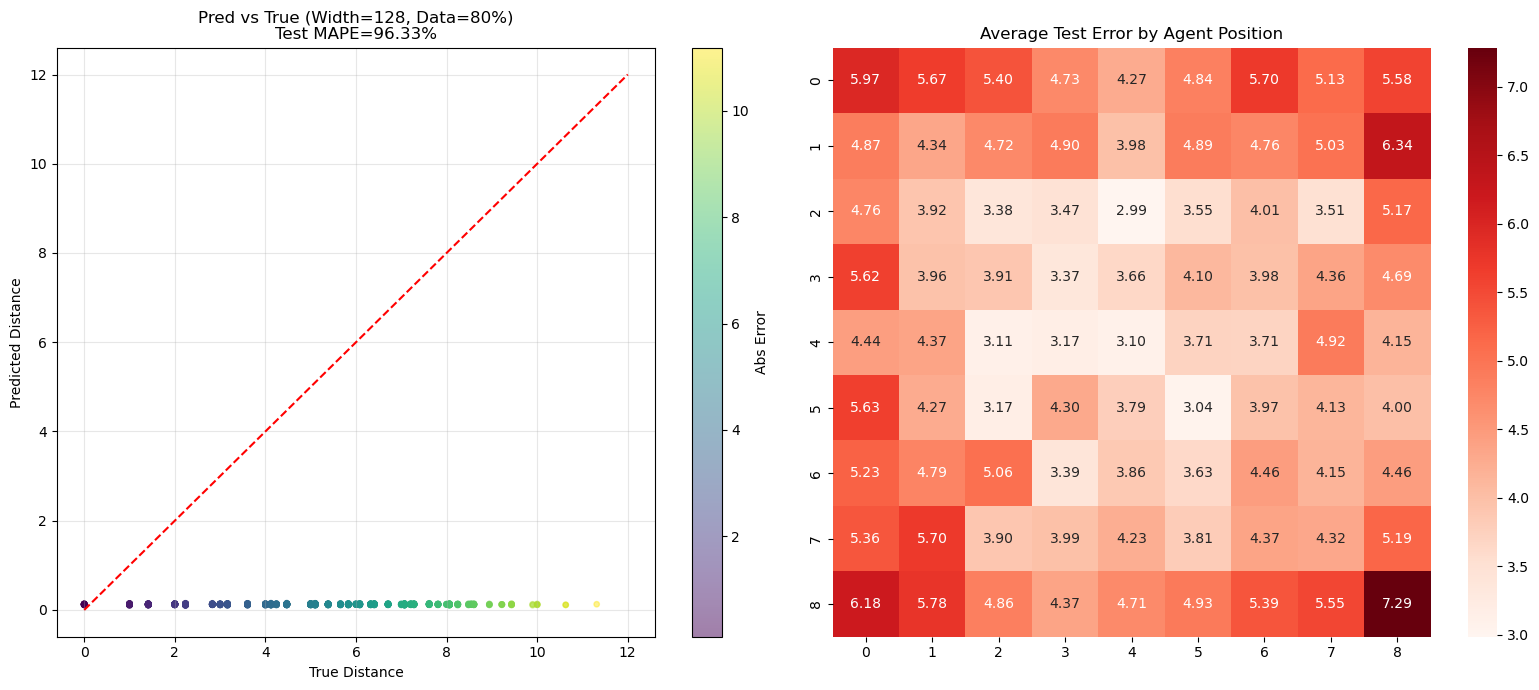

In [7]:
# Create a 2-panel plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# A. Scatter Plot (Pred vs True)
ax = axes[0]
sc = ax.scatter(test_t, test_p, alpha=0.5, c=test_err, cmap='viridis', s=15)
ax.plot([0, 12], [0, 12], 'r--', label='Perfect Line')
ax.set_title(f"Pred vs True (Width={HIDDEN_DIM}, Data={TRAIN_RATIO*100:.0f}%)\nTest MAPE={test_mape:.2f}%")
ax.set_xlabel("True Distance")
ax.set_ylabel("Predicted Distance")
plt.colorbar(sc, ax=ax, label="Abs Error")
ax.grid(True, alpha=0.3)

# B. Heatmap (Average Error by Agent Position)
# This detects if the model fails at the edges/corners
ax = axes[1]
error_grid = np.zeros((GRID_SIZE, GRID_SIZE))
count_grid = np.zeros((GRID_SIZE, GRID_SIZE))

for i, (_, _, p1) in enumerate(test_data):
    r, c = p1
    error_grid[r, c] += test_err[i]
    count_grid[r, c] += 1

# Avoid divide by zero
count_grid[count_grid == 0] = 1
avg_error_grid = error_grid / count_grid

sns.heatmap(avg_error_grid, annot=True, fmt=".2f", cmap="Reds", ax=ax)
ax.set_title("Average Test Error by Agent Position")

plt.tight_layout()
plot_path = f"plots/analysis_{JOB_ID}.png"
plt.savefig(plot_path)
print(f"Saved visualization to {plot_path}")

In [8]:
results = {
    "job_id": JOB_ID,
    "hidden_dim": HIDDEN_DIM,
    "layers": NUM_LAYERS,
    "train_ratio": TRAIN_RATIO,
    "train_mae": train_mae,
    "test_mae": test_mae,
    "test_mape": test_mape,
    "zero_mae": zero_mae,
    "params": param_count
}

df = pd.DataFrame([results])
# Append to CSV, create header only if file doesn't exist
df.to_csv(OUTPUT_FILE, mode='a', header=not os.path.exists(OUTPUT_FILE), index=False)
print("Results appended to CSV.")

Results appended to CSV.
